In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm
from vnstock import Vnstock
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [24]:
stock = Vnstock().stock(symbol="VNINDEX", source="VCI")
df = stock.quote.history(
    start="2024-01-01",
    end="2026-03-29",
    interval="1D"
)

2026-03-29 13:17:05 - vnstock.common.data - INFO - Not a stock. Company and finance data unavailable.


In [25]:
df["time"] = pd.to_datetime(df["time"])
df.set_index("time", inplace=True)
df.sort_index(inplace=True)
close = df["close"].asfreq("B").ffill()
print(close.tail())
print(f"Số quan sát: {len(close)}")

time
2026-03-23    1591.17
2026-03-24    1614.77
2026-03-25    1658.19
2026-03-26    1644.63
2026-03-27    1672.80
Freq: B, Name: close, dtype: float64
Số quan sát: 618


In [26]:
def adf_test(series, name="Chuỗi"):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"\n=== ADF Test: {name} ===")
    print(f"  Thống kê ADF : {result[0]:.4f}")
    print(f"  P-value      : {result[1]:.4f}")
    print(f"  Lag tối ưu   : {result[2]}")
    print(f"  Giá trị tới hạn:")
    for k, v in result[4].items():
        print(f"    {k}: {v:.4f}")
    if result[1] < 0.05:
        print("  => Kết luận: DỪNG (bác bỏ H0)")
    else:
        print("  => Kết luận: KHÔNG DỪNG (không bác bỏ H0) — cần lấy sai phân")

adf_test(close, "VNINDEX (giá gốc)")
adf_test(close.diff(), "VNINDEX (sai phân bậc 1)")


=== ADF Test: VNINDEX (giá gốc) ===
  Thống kê ADF : -1.0041
  P-value      : 0.7518
  Lag tối ưu   : 10
  Giá trị tới hạn:
    1%: -3.4412
    5%: -2.8663
    10%: -2.5693
  => Kết luận: KHÔNG DỪNG (không bác bỏ H0) — cần lấy sai phân

=== ADF Test: VNINDEX (sai phân bậc 1) ===
  Thống kê ADF : -7.0781
  P-value      : 0.0000
  Lag tối ưu   : 9
  Giá trị tới hạn:
    1%: -3.4412
    5%: -2.8663
    10%: -2.5693
  => Kết luận: DỪNG (bác bỏ H0)


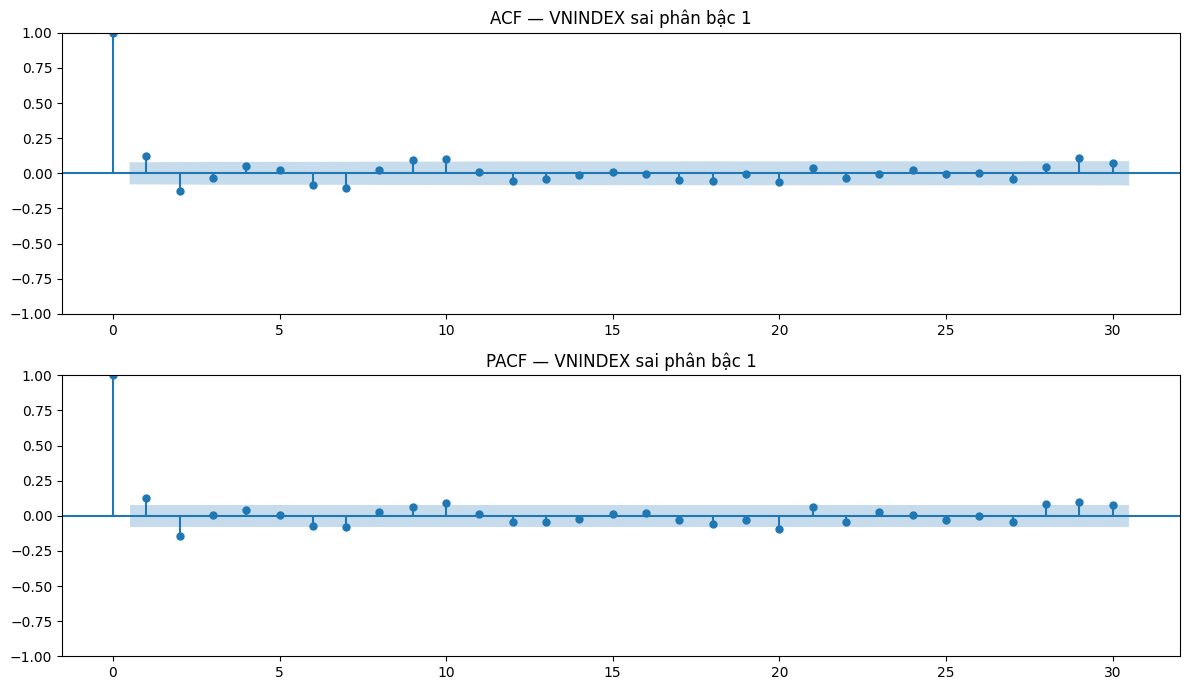

In [27]:
diff1 = close.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

plot_acf(diff1, lags=30, ax=axes[0], title="ACF — VNINDEX sai phân bậc 1")
plot_pacf(diff1, lags=30, ax=axes[1], title="PACF — VNINDEX sai phân bậc 1", method="ywm")

plt.tight_layout()
plt.show()

In [28]:
auto_model = pm.auto_arima(
    close,
    d=1,                
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    seasonal=False,
    information_criterion="aic",
    stepwise=True,      
    trace=True,    
    error_action="ignore",
    suppress_warnings=True
)

print(f"\nMô hình tốt nhất: ARIMA{auto_model.order}")
print(f"AIC: {auto_model.aic():.2f}")
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=5216.384, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=5208.516, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=5204.919, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=5216.178, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=5202.265, Time=0.06 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=5199.043, Time=0.13 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=5197.052, Time=0.04 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=5199.038, Time=0.05 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=5200.931, Time=0.15 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=5196.953, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=5207.927, Time=0.02 sec
 ARIMA(3,1,0)(0,0,0)[0]             : AIC=5198.918, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=5198.930, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=5201.770, Time=0.03 sec
 ARIMA(3,1,1)(0,0,0)[0]          

In [29]:
p, d, q = auto_model.order

train_size = int(len(close) * 0.8)
train = close.iloc[:train_size]
test  = close.iloc[train_size:]

print(f"Train: {len(train)} quan sát | Test: {len(test)} quan sát")

model = SARIMAX(train, order=(p, d, q),
                trend="c",         
                enforce_stationarity=True,
                enforce_invertibility=True)

result = model.fit(disp=False)
print(result.summary())

Train: 494 quan sát | Test: 124 quan sát
                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                  494
Model:               SARIMAX(2, 1, 0)   Log Likelihood               -1977.597
Date:                Sun, 29 Mar 2026   AIC                           3963.193
Time:                        13:17:08   BIC                           3979.995
Sample:                    11-15-2023   HQIC                          3969.790
                         - 10-06-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.2007      0.689      1.742      0.081      -0.150       2.551
ar.L1          0.0519      0.027      1.921      0.055      -0.001       0.105
ar.L2      

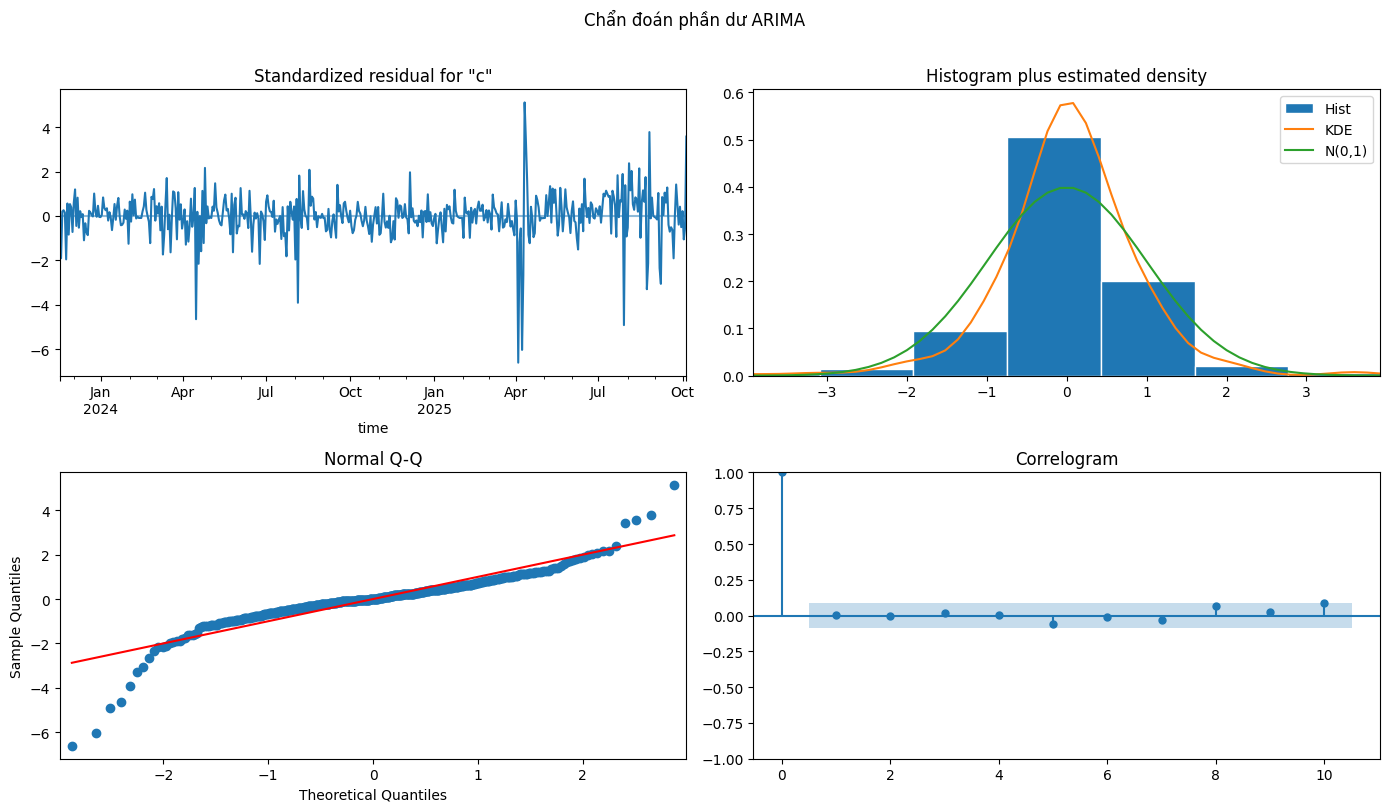


Ljung-Box test:
     lb_stat  lb_pvalue
10  0.595008   0.999985
20  0.953845   1.000000


In [30]:
result.plot_diagnostics(figsize=(14, 8))
plt.suptitle("Chẩn đoán phần dư ARIMA", y=1.01)
plt.tight_layout()
plt.show()

lb = acorr_ljungbox(result.resid, lags=[10, 20], return_df=True)
print("\nLjung-Box test:")
print(lb)

In [31]:
n_steps = len(test)

forecast_obj = result.get_forecast(steps=n_steps)
forecast_mean = forecast_obj.predicted_mean
forecast_ci   = forecast_obj.conf_int(alpha=0.05)

mae  = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mean_squared_error(test, forecast_mean))
mape = np.mean(np.abs((test.values - forecast_mean.values) / test.values)) * 100

print(f"\n=== Kết quả dự báo trên tập test ===")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")


=== Kết quả dự báo trên tập test ===
MAE  : 63.53
RMSE : 80.88
MAPE : 3.71%


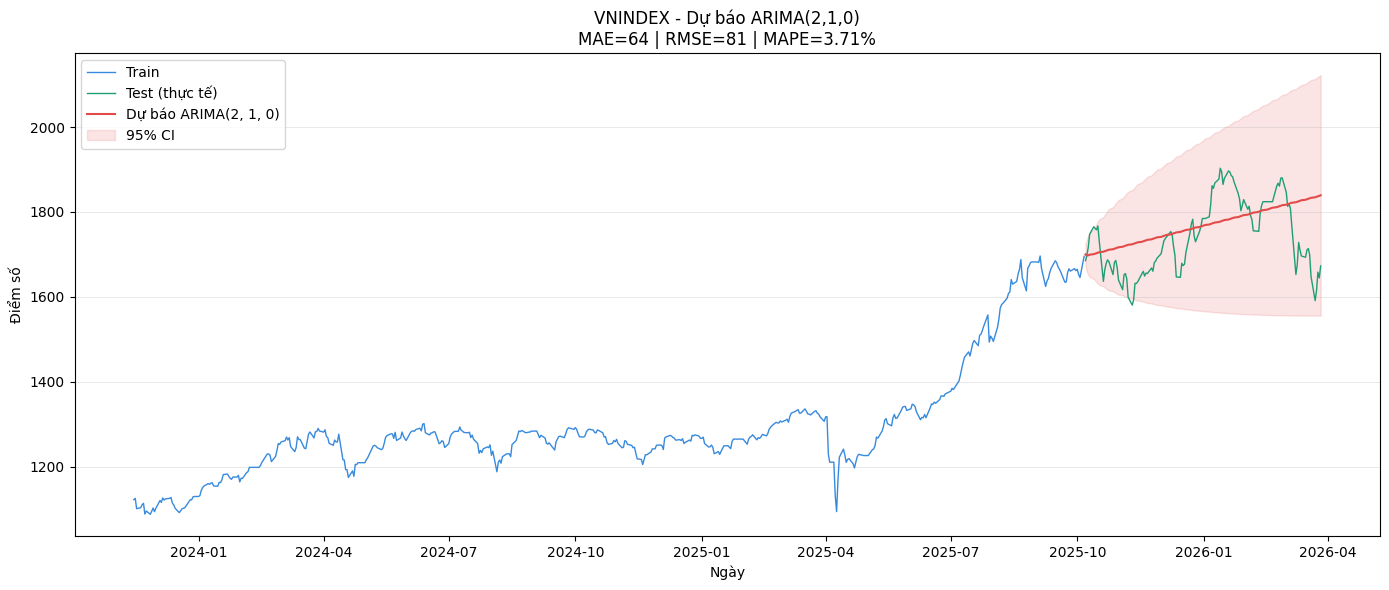

In [32]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train.index, train, color="#378ADD", linewidth=1, label="Train")
ax.plot(test.index,  test,  color="#1D9E75", linewidth=1, label="Test (thực tế)")

ax.plot(forecast_mean.index, forecast_mean,
        color="#E24B4A", linewidth=1.5, label=f"Dự báo ARIMA{(p,d,q)}")
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                color="#E24B4A", alpha=0.15, label="95% CI")

ax.set_title(f"VNINDEX - Dự báo ARIMA({p},{d},{q})\nMAE={mae:.0f} | RMSE={rmse:.0f} | MAPE={mape:.2f}%")
ax.set_xlabel("Ngày")
ax.set_ylabel("Điểm số")
ax.legend()
ax.grid(axis="y", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.show()

In [33]:
final_model = SARIMAX(close, order=(p, d, q), trend="c").fit(disp=False)

future = final_model.get_forecast(steps=30)
future_mean = future.predicted_mean
future_ci   = future.conf_int(alpha=0.05)

future_mean.index = pd.bdate_range(start=close.index[-1], periods=31)[1:]
future_ci.index   = future_mean.index

print("\n=== Dự báo 30 ngày tới ===")
print(pd.DataFrame({
    "Dự báo":       future_mean.round(2),
    "CI thấp (95%)": future_ci.iloc[:,0].round(2),
    "CI cao (95%)":  future_ci.iloc[:,1].round(2)
}))


=== Dự báo 30 ngày tới ===
             Dự báo  CI thấp (95%)  CI cao (95%)
2026-03-30  1679.79        1648.00       1711.59
2026-03-31  1677.56        1629.23       1725.90
2026-04-01  1677.11        1618.93       1735.30
2026-04-02  1678.28        1612.29       1744.27
2026-04-03  1679.42        1606.29       1752.56
2026-04-06  1680.32        1600.58       1760.07
2026-04-07  1681.19        1595.35       1767.03
2026-04-08  1682.09        1590.58       1773.60
2026-04-09  1683.00        1586.15       1779.85
2026-04-10  1683.90        1581.99       1785.81
2026-04-13  1684.80        1578.07       1791.54
2026-04-14  1685.71        1574.36       1797.06
2026-04-15  1686.61        1570.83       1802.39
2026-04-16  1687.51        1567.47       1807.56
2026-04-17  1688.42        1564.25       1812.58
2026-04-20  1689.32        1561.16       1817.48
2026-04-21  1690.22        1558.20       1822.25
2026-04-22  1691.13        1555.35       1826.91
2026-04-23  1692.03        1552.59       